# Power Rabi: load saved arrays → plot → fit

This notebook is analysis-only:

- Load the saved `data.json` + `arrays.npz` (DataHandler format)
- Plot the raw arrays and normalized signal
- Fit the oscillation


## 1) Imports + locate NV2_array


In [2]:
from __future__ import annotations
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from importlib import reload
import nv2_analysis.fits as fits

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "qua-libs").exists():
            return p

WORKSPACE = find_workspace_root(Path.cwd())

ANALYSIS = (WORKSPACE / "qua-libs/Quantum-Control-Applications/Optically addressable spin qubits/NV2_array/analysis").resolve()

NV2 = ANALYSIS.parent

DATA_ROOT = NV2 / "Data"

sys.path.insert(0, str(ANALYSIS))

from nv2_analysis.dataset import DatasetReader  # noqa: E402
from nv2_analysis.fits import ExperimentFitter  # noqa: E402

plt.rcParams["figure.figsize"] = (9, 5)

CC_NS = 4.0 # 4 ns per clock cycle

## 2) Load saved arrays


In [3]:
reader = DatasetReader(nv_root=NV2, data_root=DATA_ROOT)

EXPERIMENT_TAG = "power_rabi"  # matches dataset folder names like '#17_power_rabi_155155'

# Choose a specific dataset folder or leave None for "latest":
#   DATASET = None
#   DATASET = r"2025-12-31\#17_power_rabi_155155"  # relative to Data/
#   DATASET = r"C:\\...\\NV2_array\\Data\\2025-12-31\\#17_power_rabi_155155"  # absolute

DATASET = None

def find_latest_by_tag(tag: str) -> Path:
    candidates = [p.parent for p in DATA_ROOT.rglob("data.json") if p.is_file() and tag in p.parent.name]
    if not candidates:
        raise FileNotFoundError(f"No datasets matching tag {tag!r} under {DATA_ROOT}")
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

ds_folder = find_latest_by_tag(EXPERIMENT_TAG) if DATASET is None else reader.resolve_dataset(DATASET).folder
ds = reader.resolve_dataset(ds_folder)

data = reader.load(ds)

a_vec = np.asarray(data["a_vec"], dtype=float)  # amplitude pre-factors
counts_data = np.asarray(data["counts_data"], dtype=float)
counts_ref_data = np.asarray(data["counts_ref_data"], dtype=float)

cfg = data.get("config") or {}
pulses = cfg.get("pulses") or {}
waveforms = cfg.get("waveforms") or {}
readout_len_ns = float(pulses["readout_pulse_1"]["length"])  # meas_len_1
meas_len_s = readout_len_ns * 1e-9

# Get x180 amplitude from waveform definition (same as x180_amp_NV in experiment script)
x180_amp = float(waveforms.get("x180_wf", {}).get("sample", 1.0))
amp_volts = a_vec * x180_amp  # Same as a_vec * x180_amp_NV in experiment

signal_kcps = counts_data / 1000.0 / meas_len_s
ref_kcps = counts_ref_data / 1000.0 / meas_len_s

normalized_data = -(ref_kcps - signal_kcps) / ref_kcps

print(f"Loaded: {ds.folder}")
print(f"x180_amp_NV: {x180_amp} V")
print(f"a_vec range: [{a_vec.min():.3f}, {a_vec.max():.3f}]")
print(f"amp_volts range: [{amp_volts.min():.3f}, {amp_volts.max():.3f}] V")


Loaded: C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array\Data\2026-02-24\#229_power_rabi_154319
x180_amp_NV: 0.18 V
a_vec range: [0.000, 1.960]
amp_volts range: [0.000, 0.353] V


## 3) Plot original arrays


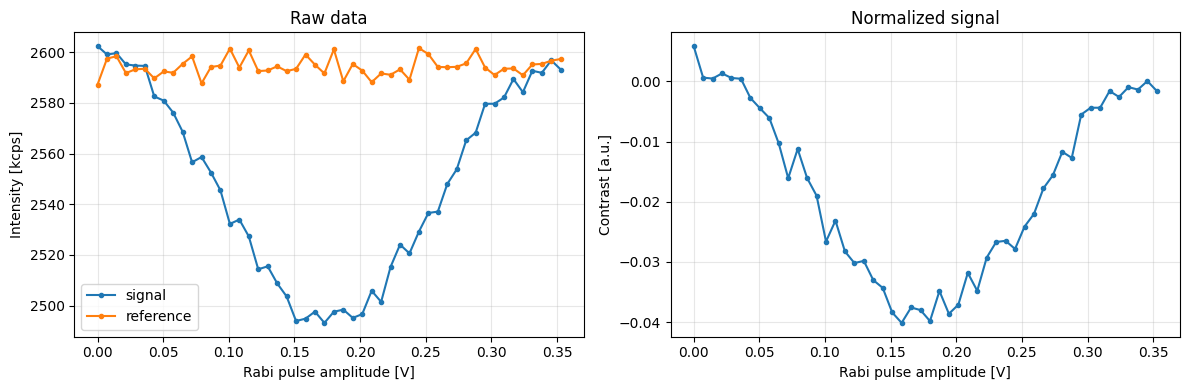

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(amp_volts, signal_kcps, "o-", ms=3, label="signal")
ax[0].plot(amp_volts, ref_kcps, "o-", ms=3, label="reference")
ax[0].set_xlabel("Rabi pulse amplitude [V]")
ax[0].set_ylabel("Intensity [kcps]")
ax[0].set_title("Raw data")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(amp_volts, normalized_data, "o-", ms=3)
ax[1].set_xlabel("Rabi pulse amplitude [V]")
ax[1].set_ylabel("Contrast [a.u.]")
ax[1].set_title("Normalized signal")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4) Fit


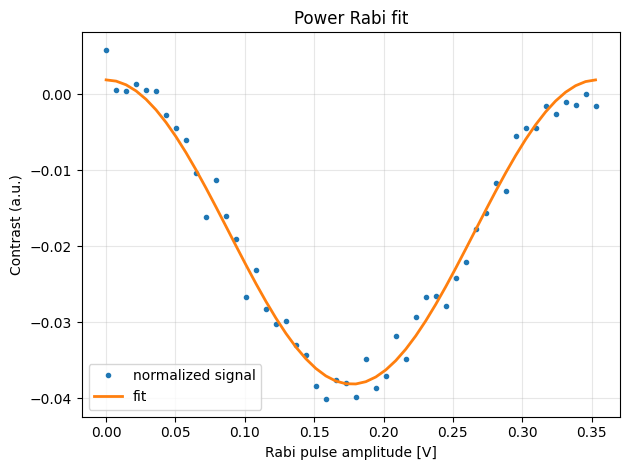

Fit function:
y(A) = amp * cos(2π f A + phase) + offset
  amp=0.020016871600250438, f=2.824500040917613 1/V, phase=0.0 rad, offset=-0.018122765613307185, T=nan V

Derived amplitudes:
- period: 0.3540 V
- A_pi (half-period): 0.1770 V
- A_pi (phase-adjusted, first cos minimum): 0.1770 V


In [6]:
reload(fits)
fitter = fits.ExperimentFitter()

# Prepare dataset for fit_power_rabi
dataset = {
    "a_vec": a_vec,
    "normalized_data": normalized_data
}
fit_res = fitter.fit_power_rabi(dataset, x180_amp_nv=x180_amp)

x = getattr(fit_res, 'x', None)
y = getattr(fit_res, 'y', None)
y_fit = getattr(fit_res, 'y_fit', None)
if x is None:
    x = amp_volts
if y is None:
    y = normalized_data

plt.figure(figsize=(6.4, 4.8))
plt.plot(x, y, 'o', ms=3, label='normalized signal')
if y_fit is not None:
    plt.plot(x, y_fit, '-', lw=2, label='fit')
plt.xlabel('Rabi pulse amplitude [V]')
plt.ylabel('Contrast (a.u.)')
plt.title('Power Rabi fit')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Then print fit details
def as_scalar(v):
    try:
        a = np.asarray(v, dtype=float).ravel()
        return float(a[0]) if a.size else None
    except Exception:
        return None

amp = as_scalar(fit_res.params.get('amp'))
f = as_scalar(fit_res.params.get('f'))
phase = as_scalar(fit_res.params.get('phase'))
offset = as_scalar(fit_res.params.get('offset'))
T = as_scalar(fit_res.params.get('T'))

print('Fit function:')
if all(v is not None for v in [amp, f, phase, offset]):
    if T is not None and T > 0:
        print('y(A) = amp * cos(2π f A + phase) * exp(-A/T) + offset')
    else:
        print('y(A) = amp * cos(2π f A + phase) + offset')
    print(f'  amp={amp}, f={f} 1/V, phase={phase} rad, offset={offset}, T={T} V')
else:
    print('Could not format analytic function (missing amp/f/phase/offset).')

print('\nDerived amplitudes:')
if f is not None and f > 0:
    period_V = 1.0 / f
    A_pi_halfperiod_V = 0.5 / f
    print(f'- period: {period_V:.4f} V')
    print(f'- A_pi (half-period): {A_pi_halfperiod_V:.4f} V')
    if phase is not None:
        A_pi_phase_V = ((np.pi - phase) % (2.0 * np.pi)) / (2.0 * np.pi * f)
        print(f'- A_pi (phase-adjusted, first cos minimum): {A_pi_phase_V:.4f} V')
else:
    print('Could not compute A_pi (missing/invalid f).')
